In [1]:
%matplotlib widget 
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from scipy.optimize import linear_sum_assignment
import cv2
from scipy.interpolate import RBFInterpolator
import pandas as pd
import re

from misc2 import read_tomo_file, pair_func, XYZTransform


# first, roughly check the alignment between tomo and psfe

In [2]:
# read tomo localizations

tomo_folder = os.path.join(os.getcwd(), "data", "D50_TP_Swirl_R2_stb")


tomo_files = sorted(os.listdir(tomo_folder))
num_tomo = len(tomo_files)
tomo_locs = []
for i in range(num_tomo):
    df = read_tomo_file(os.path.join(tomo_folder, tomo_files[i]))
    loc = df[['x[mm]', 'y[mm]', 'z[mm]']].to_numpy()
    tomo_locs.append(loc)
    
print(f'# of frames: {num_tomo}')
print(f'column names: {list(df.columns)}')

df.head()

# of frames: 1
column names: ['x[mm]', 'y[mm]', 'z[mm]', 'I', 'Vx[m/s]', 'Vy[m/s]', 'Vz[m/s]', '|V|[m/s]', 'trackID', 'Ax[m/sֲ²]', 'Ay[m/sֲ²]', 'Az[m/sֲ²]', '|A|[m/sֲ²]', 'Absolute intensity[]', 'UncertaintyX[mm]', 'UncertaintyY[mm]', 'UncertaintyZ[mm]', 'UncertaintyVx[m/s]', 'UncertaintyVy[m/s]', 'UncertaintyVz[m/s]', 'UncertaintyV[m/s]', 'UncertaintyAx[m/sֲ²]', 'UncertaintyAy[m/sֲ²]', 'UncertaintyAz[m/sֲ²]', 'UncertaintyA[m/sֲ²]']


,x[mm],y[mm],z[mm],I,Vx[m/s],Vy[m/s],Vz[m/s],|V|[m/s],trackID,Ax[m/sֲ²],...,UncertaintyY[mm],UncertaintyZ[mm],UncertaintyVx[m/s],UncertaintyVy[m/s],UncertaintyVz[m/s],UncertaintyV[m/s],UncertaintyAx[m/sֲ²],UncertaintyAy[m/sֲ²],UncertaintyAz[m/sֲ²],UncertaintyA[m/sֲ²]
0,-45.21,-26.54,0.8728,0.4326,-0.001431,0.018900,-0.2007,0.2016,0,-12.63,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,31.94,10.60,19.7300,1.4650,-0.115800,0.005706,0.1993,0.2306,1,30.01,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-20.24,-15.62,0.3680,0.4239,0.021290,0.012170,-0.2270,0.2283,2,-68.05,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,27.64,11.74,19.6800,1.5600,-0.115400,0.049220,0.1310,0.1814,3,27.16,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,21.97,16.35,19.7300,1.6680,-0.128300,0.030630,0.1360,0.1895,4,47.21,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


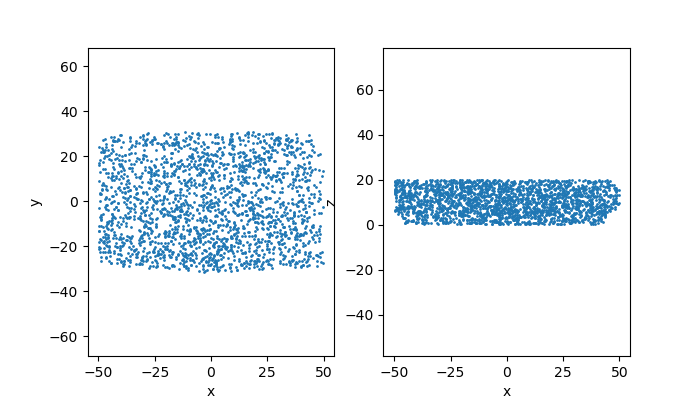

In [3]:
# show tomo
locs_show = tomo_locs[:1]  # tomo_locs is a list 

fig = plt.figure(figsize=(7, 4))
fig.add_subplot(121)
for loc in locs_show:
    plt.plot(loc[:, 0], loc[:, 1], '.', markersize=2)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
fig.add_subplot(122)
for loc in locs_show:
    plt.plot(loc[:, 0], loc[:, 2], '.', markersize=2)
plt.xlabel('x')
plt.ylabel('z')
plt.axis('equal')

plt.show()

In [4]:
# raw PSFE localizations: x, y, z, intensity, and frame number

psfe_file = os.path.join(os.getcwd(), "data", "D50_TP_Swirl_R2_loc_01-27_09-46")
psfe_data = np.loadtxt(psfe_file)

# data 1216,  adjust this !!!!!!!!!!!
xyz_sign = (1, -1, 1)
xyz_shift = (0.0, 0.0, 10.0)

psfe_data[:, 0] = psfe_data[:, 0] * xyz_sign[0] + xyz_shift[0]
psfe_data[:, 1] = psfe_data[:, 1] * xyz_sign[1] + xyz_shift[1]
psfe_data[:, 2] = psfe_data[:, 2] * xyz_sign[2] + xyz_shift[2]

num_psfe = int(psfe_data[-1, -1] + 1)
psfe_locs = []
for i in range(num_psfe):
    loc = psfe_data[psfe_data[:, -1]==i, :3]  # only take x y z
    psfe_locs.append(loc)

print(f'# of frames: {num_psfe}')

# of frames: 1


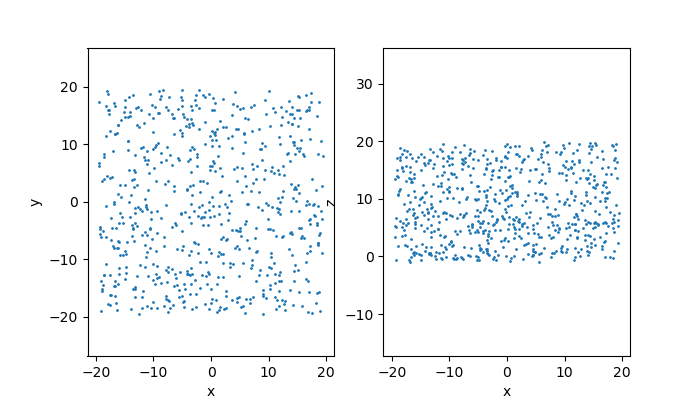

In [5]:
# show 
locs_show = psfe_locs[:1]

fig = plt.figure(figsize=(7, 4))
fig.add_subplot(121)
for loc in locs_show:
    plt.plot(loc[:, 0], loc[:, 1], '.', markersize=2)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')    
fig.add_subplot(122)
for loc in locs_show:
    plt.plot(loc[:, 0], loc[:, 2], '.', markersize=2)
plt.xlabel('x')
plt.ylabel('z')
plt.axis('equal')

plt.show()

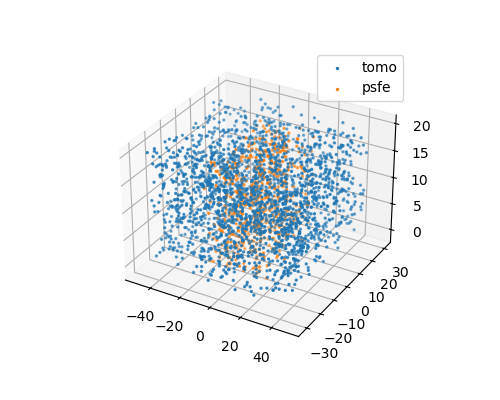

In [6]:
# show one frame of data 
idx = 0
loc1, loc0 = psfe_locs[idx], tomo_locs[idx]

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(loc0[:, 0], loc0[:, 1], loc0[:, 2], s=2, label='tomo')
ax.scatter(loc1[:, 0], loc1[:, 1], loc1[:, 2], s=2, label='psfe')
plt.legend()
plt.show()

# match making 

In [7]:
# iteratively find the correspondence between tomo and psfe detections

# ids = np.arange(0, 500, 400)
ids = [0]

radius = 1.0
num_iter = 10

tomo_locs_copy = tomo_locs.copy()
psfe_locs_copy = psfe_locs.copy()

affineM = np.eye(4, 4)  # increamental affine
affineM_final = np.eye(4, 4)  # accumulated affine 

num_pairs = []
for ii in range(num_iter):
    
    loc_set0 = []
    loc_set1 = []
    loc_set0_ = []
    loc_set1_ = []
    
    for idx in ids:
        xyzs0, xyzs1 = tomo_locs_copy[idx], psfe_locs_copy[idx] # frame data
        # transform psfe coordinates
        xyzs1 = (affineM @ np.c_[(xyzs1, np.ones((xyzs1.shape[0], 1)))].T)[:3, :].T
        psfe_locs_copy[idx] = xyzs1  # update
        
        # xyzs1 = affineM_final @ np.c_[(xyzs1, np.ones((xyzs1.shape[0], 1)))].T
        # xyzs1 = xyzs1[:3, :].T
        
        pair_result = pair_func(xyzs0, xyzs1, radius)  # pair

        if pair_result is not None:
            ids0, ids1 =  pair_result
            
            # transformed coordinates 
            loc_set0.append(xyzs0[ids0])
            loc_set1.append(xyzs1[ids1])
            # raw coordinates
            loc_set0_.append(tomo_locs[idx][ids0])
            loc_set1_.append(psfe_locs[idx][ids1])
           
    loc_set0 = np.concatenate(loc_set0, axis=0)
    loc_set1 = np.concatenate(loc_set1, axis=0)
    num_pairs.append(loc_set0.shape[0])
    
    # increamental transform matrix
    retval, affine_matrix, inliers = cv2.estimateAffine3D(loc_set1, 
                                                          loc_set0, 
                                                          ransacThreshold=1.0, 
                                                          confidence=0.99)
    affineM = np.vstack([affine_matrix, [0, 0, 0, 1]])
    affineM_final = affineM@affineM_final  # accumulation

# matched raw coordinates
loc_set0_ = np.concatenate(loc_set0_, axis=0)
loc_set1_ = np.concatenate(loc_set1_, axis=0)

print(f'iterative matched pair number: {num_pairs}')
print(f'accumulated affine matrix: \n{affineM_final}')

iterative matched pair number: [421, 560, 552, 579, 553, 562, 556, 552, 556, 537]
accumulated affine matrix: 
[[ 1.00732182  0.00511223  0.01599274 -0.07343725]
 [-0.00326231  1.00544369 -0.020441    0.07602965]
 [-0.01802056  0.00549008  1.05327926  0.12195645]
 [ 0.          0.          0.          1.        ]]


In [8]:
retval, affine_matrix, inliers = cv2.estimateAffine3D(loc_set1_, 
                                                      loc_set0_, 
                                                      ransacThreshold=1.0, 
                                                      confidence=0.99)


affine_total = np.vstack([affine_matrix, [0, 0, 0, 1]])
print(f'inliers: {inliers.sum()}/{loc_set1_.shape[0]}')
print(affine_total)

inliers: 532/537
[[ 1.00732185  0.00511223  0.01599275 -0.07343718]
 [-0.0032623   1.00544372 -0.02044101  0.07602961]
 [-0.01802055  0.00549009  1.05327922  0.12195667]
 [ 0.          0.          0.          1.        ]]


In [9]:
# alignment dict
loc_set0_inliers = loc_set0_[inliers[:, 0]==1]
loc_set1_inliers = loc_set1_[inliers[:, 0]==1]

alignment_dict = {'xyz_set0':loc_set0_inliers,
                  'xyz_set1':loc_set1_inliers,
                  'affine3x4': affine_matrix,
                  'xyz_sign': xyz_sign,
                  'xyz_shift': xyz_shift
                 }

xyzfunc = XYZTransform(alignment_dict)


In [10]:
loc_set1_aff = xyzfunc.direct_transform(loc_set1_) 
loc_set1_aff_in = loc_set1_aff[inliers[:, 0]==1]
loc_set1_aff_out = loc_set1_aff[inliers[:, 0]==0]

rmse = np.mean(np.sqrt(np.sum((loc_set0_inliers - loc_set1_aff[inliers[:, 0]==1]) ** 2, 1)))
print(f'RMSE: {rmse} mm')

RMSE: 0.08887560792070155 mm


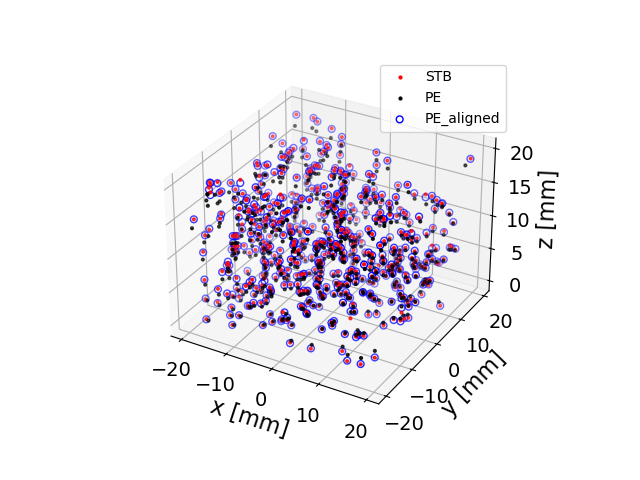

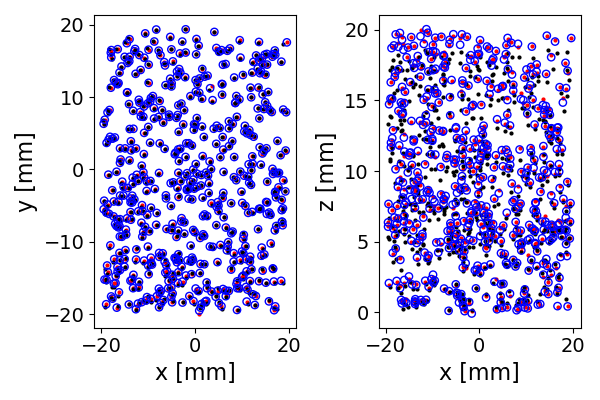

In [11]:
# show
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(loc_set0_[:, 0], loc_set0_[:, 1], loc_set0_[:, 2], s=4, color='red', label='STB')
ax.scatter(loc_set1_[:, 0], loc_set1_[:, 1], loc_set1_[:, 2], s=4, color='black', label='PE')
ax.scatter(loc_set1_aff[:, 0], loc_set1_aff[:, 1], loc_set1_aff[:, 2], s=24, facecolors='none', edgecolors='blue', label='PE_aligned')
ax.set_xlabel('x [mm]', fontsize=16)
ax.set_ylabel('y [mm]', fontsize=16)
ax.set_zlabel('z [mm]', fontsize=16)
ax.tick_params(labelsize=14)
plt.legend()
# plt.savefig('alignment3d.png', dpi=600)

plt.show()

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(121)
ax.scatter(loc_set0_[:, 0], loc_set0_[:, 1], s=4, color='red', label='STB')
ax.scatter(loc_set1_[:, 0], loc_set1_[:, 1], s=4, color='black', label='PE')
ax.scatter(loc_set1_aff[:, 0], loc_set1_aff[:, 1], s=28, facecolors='none', edgecolors='blue', label='PE_aligned')
ax.set_xlabel('x [mm]', fontsize=16)
ax.set_ylabel('y [mm]', fontsize=16)
ax.tick_params(labelsize=14)

ax = fig.add_subplot(122)
ax.scatter(loc_set0_[:, 0], loc_set0_[:, 2], s=4, color='red', label='STB')
ax.scatter(loc_set1_[:, 0], loc_set1_[:, 2], s=4, color='black', label='PE')
ax.scatter(loc_set1_aff[:, 0], loc_set1_aff[:, 2], s=28, facecolors='none', edgecolors='blue', label='PE_aligned')
ax.set_xlabel('x [mm]', fontsize=16)
ax.set_ylabel('z [mm]', fontsize=16)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('alignment2d.png', dpi=600)
plt.show()


In [21]:
# save
# np.save('alignment16_0127_1000.npy', alignment_dict)  # alignment for the new net of tp16


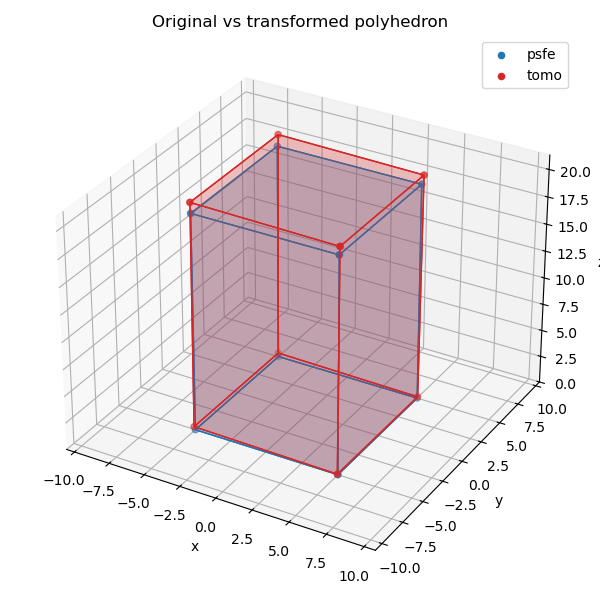

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- inputs (edit these) ----
rrr = 5
pts = np.array([
    [-rrr,-rrr,0], [rrr,-rrr,0], [rrr,rrr,0], [-rrr,rrr,0],
    [-rrr,-rrr,20], [rrr,-rrr,20], [rrr,rrr,20], [-rrr,rrr,20]
], float)

# A = np.linalg.inv(affineM_final)
A = affineM_final

# ---- apply transform ----
Ph = np.c_[pts, np.ones(len(pts))]     # (8,4)
Qh = Ph @ A.T                           # (8,4)

pts_t = Qh[:, :3] / Qh[:, [3]]          # back to (8,3)
pts_t = Qh[:, :3] / Qh[:, [3]] 

# ---- faces (quads) in this vertex order ----
faces = [
    [0,1,2,3], [4,5,6,7], [0,1,5,4],
    [1,2,6,5], [2,3,7,6], [3,0,4,7]
]

# ---- plot both ----
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.add_collection3d(Poly3DCollection([pts[f]   for f in faces], facecolor='C0', edgecolor='C0', alpha=0.15))
ax.add_collection3d(Poly3DCollection([pts_t[f] for f in faces], facecolor='C3', edgecolor='C3', alpha=0.15))
ax.scatter(*pts.T,   c='C0', s=20, label='psfe')
ax.scatter(*pts_t.T, c='C3', s=20, label='tomo')

# equal aspect
P = np.vstack([pts, pts_t])
mins, maxs = P.min(0), P.max(0)
ctr, r = (mins+maxs)/2, (maxs-mins).max()/2
ax.set_xlim(ctr[0]-r, ctr[0]+r); ax.set_ylim(ctr[1]-r, ctr[1]+r); ax.set_zlim(ctr[2]-r, ctr[2]+r)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.legend(); ax.set_title("Original vs transformed polyhedron")
plt.tight_layout(); plt.show()
